# Supervised Learning for Text: Classification

We train and compare the classifiers from the lecture on **Machine Learning for Text Analytics**:
Naive Bayes, logistic regression, linear SVMs, decision trees and a few others.

The corpus is **20 newsgroups**, four categories.

In [1]:
# Run once if you are not using the course environment.
# %pip install -q numpy pandas scikit-learn matplotlib

---
## The data

In the previous notebook we kept the posts exactly as written. This time we remove **headers**,
**signatures** and **quoted replies**, so that the classifier has to learn from what each author
actually wrote. The last section shows what happens if we do not.

In [2]:
import numpy as np
import pandas as pd
from sklearn.datasets import fetch_20newsgroups

categories = ["comp.graphics", "rec.autos", "sci.space", "talk.politics.mideast"]
clean = ("headers", "footers", "quotes")

train = fetch_20newsgroups(subset="train", categories=categories, remove=clean)
test = fetch_20newsgroups(subset="test", categories=categories, remove=clean)

x_train, y_train = train.data, train.target
x_test, y_test = test.data, test.target
class_names = train.target_names

print(f"{len(x_train)} training posts, {len(x_test)} test posts")

2335 training posts, 1555 test posts


The labels are integers, one per class. The four classes are almost balanced:

In [3]:
pd.DataFrame({
    "train": np.bincount(y_train),
    "test": np.bincount(y_test),
}, index=class_names)

,train,test
comp.graphics,584,389
rec.autos,594,396
sci.space,593,394
talk.politics.mideast,564,376


In [4]:
print(class_names[y_train[3]])
print("-" * 40)
print(x_train[3].strip()[:800])

sci.space
----------------------------------------
Exactly. Some of the SPACE:1999 effects remain first-rate even today. 
 

Later on, the Andersons tried to shed their reputation as creators of some
of the worst pseudo-scientific shows in TV history by flying "Into Infinity."
This was a one-off thing done as part of BBC's "educational SF" series "The
Day After Tomorrow." The Anderson episode dealt with a spaceship capable of
reaching the speed of light ("lightship Altares"), the four-man crew eventually 
journeyed into a black hole and ended up on the far side of the galaxy (I
think). I saw this as a 9-year-old back in 1976 and liked it very much, but
then again I was a fan of SPACE:1999 so I guess I was easily satisfied in those
days:-)
---
Does anyone know if "Into Infinity" has been released on video? I have some
SPACE:1999 shows on VH


Cleaning has a cost: a few posts were *only* a quoted reply plus a signature, and are now empty.
We leave them in. A real system also receives empty or near-empty messages.

In [5]:
print(sum(len(d.strip()) == 0 for d in x_train), "empty training posts")

76 empty training posts


---
## Training and inference in scikit-learn

The lecture split supervised learning into two phases:

- **training**: from labeled data $(\mathbf{X}, \mathbf{y})$, learn the parameters
  $\hat{\boldsymbol{\theta}}$ of the model;
- **inference**: apply the trained model $f_{\hat{\boldsymbol{\theta}}}$ to new inputs, with the
  parameters fixed.

scikit-learn gives every object the same methods for the two phases:

| | Training | Inference |
|---|---|---|
| **model** (a classifier) | `fit(X, y)` | `predict(X)`, `predict_proba(X)` |
| **transformer** (a vectorizer, a scaler) | `fit(X)` | `transform(X)` |

- `fit` is the only method that **learns**. What it learns is stored in attributes whose names
  end with an underscore: `vocabulary_` and `idf_` for a vectorizer, `coef_` or
  `feature_log_prob_` for a classifier. Before `fit`, they do not exist.
- `predict` and `transform` only **apply** what was learned; they never change it.
- `fit_transform(X)` is a shortcut for `fit(X)` followed by `transform(X)` on the same data.

To know how well a trained classifier works, every classifier also has **`score(X, y)`**: it runs
inference on `X` and compares the predictions with the true labels `y`. It returns the
**accuracy**, the fraction of documents classified correctly:

$$
\text{accuracy} = \frac{\#\text{correct predictions}}{\#\text{documents}}
$$

Accuracy is the only measure we use in this notebook. The lecture on evaluation explains when it
is misleading, and what to use instead.

A vectorizer is trained too: its "parameters" are the vocabulary (and, for TF-IDF, the IDF of
each word). So the rule from the previous notebook is the same rule as here: **`fit` only on the
training set**; the test set only ever goes through `transform` and `predict`.

In [6]:
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.exceptions import NotFittedError

toy = CountVectorizer()

try:
    toy.transform(["the rocket reached orbit"])     # inference before training
except NotFittedError as e:
    print("NotFittedError:", e)

toy.fit(["the rocket reached orbit", "the car reached the garage"])   # training
print("\nlearned vocabulary_:", toy.vocabulary_)

# inference: the new sentence is mapped onto the vocabulary learned above
new = toy.transform(["the shuttle reached orbit"])
print("transform keeps:", toy.inverse_transform(new)[0], " (shuttle was never seen: dropped)")
print("vocabulary after transform is unchanged:", len(toy.vocabulary_), "words")

NotFittedError: Vocabulary not fitted or provided

learned vocabulary_: {'the': 5, 'rocket': 4, 'reached': 3, 'orbit': 2, 'car': 0, 'garage': 1}
transform keeps: ['orbit' 'reached' 'the']  (shuttle was never seen: dropped)
vocabulary after transform is unchanged: 6 words


The same two phases apply to every model in this notebook, however complex: only what happens
inside `fit` changes. For Naive Bayes it is counting, for logistic regression it is minimizing the
cross-entropy with gradient-based optimization.

---
## A binary task: is this post about space?

We start with a binary problem: **sci.space** against the other three categories.

In [7]:
SPACE = class_names.index("sci.space")

yb_train = (y_train == SPACE).astype(int)   # 1 = space, 0 = anything else
yb_test = (y_test == SPACE).astype(int)

print(f"space posts: {yb_train.mean():.0%} of train, {yb_test.mean():.0%} of test")

space posts: 25% of train, 25% of test


### A baseline first

A classifier that always answers *not space* is right three times out of four. Any model has to
beat this number. Note that this baseline never finds a single space post, and its accuracy does
not show it.

In [8]:
from sklearn.dummy import DummyClassifier

dummy = DummyClassifier(strategy="most_frequent")
dummy.fit(x_train, yb_train)                 # training: it only learns the class frequencies
print("learned class_prior_:", dummy.class_prior_.round(3))

# inference + comparison with the true labels: always the most frequent class
print(f"always 'not space': accuracy {dummy.score(x_test, yb_test):.3f}")

learned class_prior_: [0.746 0.254]
always 'not space': accuracy 0.747


### Naive Bayes, step by step

A classifier on text has two components, and **both** are trained:

1. a **vectorizer** turns the posts into a document-term matrix;
2. a **model** is learned from that matrix.

At training time we fit the vectorizer, then the model, on the training set. At inference time we
only transform the test posts and predict.

Naive Bayes gets **counts**, not TF-IDF: the model is a unigram language model per class, and its
likelihoods are estimated from word occurrences.

In [9]:
from sklearn.naive_bayes import MultinomialNB

vect = CountVectorizer(min_df=5, stop_words="english")
nb = MultinomialNB()                       # alpha=1 by default: Laplace smoothing

# TRAINING: learn the vocabulary, then the model parameters, from the training set only
X_train = vect.fit_transform(x_train)
nb.fit(X_train, yb_train)

# INFERENCE: apply what was learned to the test set, nothing is refitted
X_test = vect.transform(x_test)
nb_pred = nb.predict(X_test)

print("train matrix:", X_train.shape, " test matrix:", X_test.shape)
from sklearn.metrics import accuracy_score

print(f"Naive Bayes: accuracy {nb.score(X_test, yb_test):.3f}")   # score takes the matrix, like predict
print(f"same, from the predictions: {accuracy_score(yb_test, nb_pred):.3f}")   # score = predict + accuracy_score

train matrix: (2335, 6340)  test matrix: (1555, 6340)
Naive Bayes: accuracy 0.924
same, from the predictions: 0.924


### The same thing as a Pipeline

Keeping track of which object was fitted on what gets error-prone as soon as there are more steps,
or more models to compare. A `Pipeline` chains the steps into a single object:

- training, `fit(x_train, y)`: calls `fit_transform` on the vectorizer, then `fit` on the model;
- inference, `predict(x_test)`: calls only `transform` on the vectorizer, then `predict` on the
  model. `score(x_test, y)` does the same, then compares with `y`.

It takes the raw posts, and the fit-on-train contract is kept for us.

In [10]:
from sklearn.pipeline import Pipeline

nb_bin = Pipeline([
    ("vect", CountVectorizer(min_df=5, stop_words="english")),
    ("clf", MultinomialNB()),
])

nb_bin.fit(x_train, yb_train)              # raw text in, no X_train needed

print("same predictions as step by step:", (nb_bin.predict(x_test) == nb_pred).all())
print(f"accuracy: {nb_bin.score(x_test, yb_test):.3f}")      # raw text in, here too

same predictions as step by step: True
accuracy: 0.924


From here on every model is a pipeline. Its steps are still there, under the names we gave them,
in `named_steps`.

### What did Naive Bayes learn?

The trained model is just the priors and one smoothed unigram distribution per class.

In [11]:
vect = nb_bin.named_steps["vect"]
nb = nb_bin.named_steps["clf"]
terms = vect.get_feature_names_out()

print("vocabulary:", len(terms), "words")
print("priors:", dict(zip(["other", "space"], np.exp(nb.class_log_prior_).round(3))))
print("feature_log_prob_ shape:", nb.feature_log_prob_.shape)

vocabulary: 6340 words
priors: {'other': np.float64(0.746), 'space': np.float64(0.254)}
feature_log_prob_ shape: (2, 6340)


Which words push a post towards *space*? Compare the two likelihoods of each word. The log of
their ratio, $\log \hat{P}(w \mid \text{space}) - \log \hat{P}(w \mid \text{other})$, is the weight
each occurrence of $w$ adds to the space score, since Naive Bayes is a linear classifier.

In [12]:
log_ratio = nb.feature_log_prob_[1] - nb.feature_log_prob_[0]
order = np.argsort(log_ratio)

print("towards space:", ", ".join(terms[order[-15:]][::-1]))
print("\naway from it: ", ", ".join(terms[order[:15]]))

towards space: lunar, orbital, orbit, spacecraft, orbiter, mars, titan, satellites, launches, astronaut, ssf, redesign, propulsion, centaur, ssto

away from it:  armenian, armenians, turkish, jews, israeli, israel, armenia, turks, jewish, arab, genocide, azerbaijan, muslim, turkey, azerbaijani


### Naive Bayes is overconfident

The lecture claimed that, because correlated words are counted as independent evidence, Naive
Bayes probabilities are pushed to 0 or 1. Let's look at how sure the model is of each test
prediction.

predictions with probability > 0.99: 81%
accuracy on those predictions:       96%


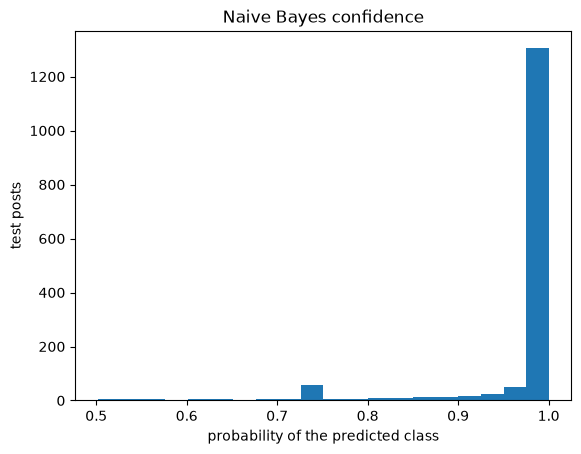

In [13]:
import matplotlib.pyplot as plt

nb_conf = nb_bin.predict_proba(x_test).max(axis=1)   # probability of the predicted class
very_sure = nb_conf > 0.99

print(f"predictions with probability > 0.99: {very_sure.mean():.0%}")
print(f"accuracy on those predictions:       {(nb_pred == yb_test)[very_sure].mean():.0%}")

plt.hist(nb_conf, bins=20)
plt.xlabel("probability of the predicted class")
plt.ylabel("test posts")
plt.title("Naive Bayes confidence")
plt.show()

Four predictions out of five come with more than 99% confidence, but those predictions are wrong
more than 1% of the time. The ranking of the classes is usually right; the probabilities are not
to be trusted.

---
## Logistic regression

Logistic regression is usually given **TF-IDF** features. `TfidfVectorizer` is the
`CountVectorizer` and `TfidfTransformer` of the previous notebook in one object.

In [14]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression

lr_bin = Pipeline([
    ("vect", TfidfVectorizer(min_df=5, stop_words="english")),
    ("clf", LogisticRegression(max_iter=1000)),
])

lr_bin.fit(x_train, yb_train)
lr_pred = lr_bin.predict(x_test)

print(f"logistic regression: accuracy {lr_bin.score(x_test, yb_test):.3f}")
print(f"posts labeled space: {lr_pred.sum()} predicted, {yb_test.sum()} in the test set")

logistic regression: accuracy 0.859
posts labeled space: 176 predicted, 394 in the test set


Worse than Naive Bayes, and the model is very reluctant to say *space*: it labels fewer than half
as many posts as there are. Keep this in mind: we come back to it
when we talk about regularization.

### The weights are readable

`coef_` holds one weight per word. Positive weights push towards *space*, negative ones away.

In [15]:
lr_terms = lr_bin.named_steps["vect"].get_feature_names_out()
lr = lr_bin.named_steps["clf"]
w, b = lr.coef_[0], lr.intercept_[0]

order = np.argsort(w)
print("towards space:", ", ".join(lr_terms[order[-15:]][::-1]))
print("\naway from it: ", ", ".join(lr_terms[order[:15]]))

towards space: space, nasa, orbit, moon, launch, earth, spacecraft, shuttle, lunar, dc, solar, flight, satellite, sci, idea

away from it:  car, graphics, israel, cars, israeli, file, image, jews, turkish, armenian, computer, armenians, 3d, dealer, ve


Naive Bayes ranked rare, very specific words first (*ssto*, *centaur*), because a word seen only in
space posts gets a large likelihood ratio however rare it is. Logistic regression ranks the frequent,
general words first (*space*, *nasa*, *orbit*), and it also learns *what space posts are not*:
*car*, *graphics*, *israel*.


### Regularization

scikit-learn's logistic regression is regularized by default with an L2 (ridge) penalty. Its
strength is set with `C`, which is the **inverse** of the $\lambda$ on the slides:
$C = 1/\lambda$. Small `C` means strong regularization, weights close to zero.

Let's vary it and compare training and test accuracy.

In [16]:
Cs = [0.01, 0.1, 1, 10, 100, 1000]
rows = []

for C in Cs:
    model = Pipeline([
        ("vect", TfidfVectorizer(min_df=5, stop_words="english")),
        ("clf", LogisticRegression(C=C, max_iter=2000)),
    ]).fit(x_train, yb_train)
    rows.append({"C": C,
                 "train accuracy": model.score(x_train, yb_train),
                 "test accuracy": model.score(x_test, yb_test)})

pd.DataFrame(rows).set_index("C").round(3)

,train accuracy,test accuracy
C,,
0.01,0.746,0.747
0.10,0.753,0.749
1.00,0.922,0.859
10.00,0.993,0.910
100.00,0.993,0.916
1000.00,0.993,0.919


- With `C = 0.01` the weights are squeezed to zero and the model predicts *not space* for every
  post: the same accuracy as the dummy baseline.
- The default `C = 1` is still too strong for this problem, which is why logistic regression lost
  to Naive Bayes above.
- From `C = 10` on, the model fits the training set almost perfectly and the test accuracy stops
  improving: the gap between the two columns is overfitting.

We just chose `C` by looking at the **test set**, which is cheating: the test set must only be used
once, at the end. The right way is to choose `C` on a validation set or with cross-validation
(see the lecture on evaluation protocols).

### L1 regularization selects words

With an L1 (lasso) penalty most weights become **exactly zero**, so the model keeps only a few words.
In scikit-learn 1.8, L1 is asked for with `l1_ratio=1`.

In [17]:
rows = []
for C in [0.1, 1, 10, 100]:
    model = Pipeline([
        ("vect", TfidfVectorizer(min_df=5, stop_words="english")),
        ("clf", LogisticRegression(C=C, l1_ratio=1, solver="liblinear")),
    ]).fit(x_train, yb_train)
    coef = model.named_steps["clf"].coef_[0]
    rows.append({"C": C,
                 "non-zero weights": int((coef != 0).sum()),
                 "out of": len(coef),
                 "test accuracy": model.score(x_test, yb_test)})

pd.DataFrame(rows).set_index("C").round(3)

,non-zero weights,out of,test accuracy
C,,,
0.1,1,6340,0.770
1.0,84,6340,0.875
10.0,510,6340,0.902
100.0,699,6340,0.907


With `C = 1`, fewer than a hundred words out of more than six thousand are kept, and the test
accuracy is no worse than the L2 model with the same `C`. These are the words:

In [18]:
l1 = Pipeline([
    ("vect", TfidfVectorizer(min_df=5, stop_words="english")),
    ("clf", LogisticRegression(C=1, l1_ratio=1, solver="liblinear")),
]).fit(x_train, yb_train)

coef = l1.named_steps["clf"].coef_[0]
names = l1.named_steps["vect"].get_feature_names_out()
kept = np.flatnonzero(coef)

print("positive:", ", ".join(names[i] for i in kept if coef[i] > 0))
print("\nnegative:", ", ".join(names[i] for i in kept if coef[i] < 0))

positive: 23, actually, allen, billion, breathing, centaur, cost, dc, development, earth, engineering, film, flight, funding, gamma, gehrels, high, idea, joke, jupiter, known, launch, liquid, long, lunar, mars, mary, mining, money, moon, nasa, orbit, pat, prize, project, real, remember, rocket, rocketry, rockets, satellite, shuttle, sky, smiley, solar, space, spacecraft, sunrise, sunset, things, thought, tom, working, yo

negative: 3d, armenian, armenians, car, cars, color, computer, does, file, files, ford, format, ftp, graphics, group, help, hi, image, israel, israeli, jewish, jews, know, looking, point, points, say, turkish, ve, video, windows


Most are what we expect. A few are **first names** (*pat*, *allen*, *tom*, *mary*): people who
post a lot to *sci.space* and sign their messages in the body, where the cleaning cannot reach. Keep
them in mind for the last section.

---
## Multiclass classification

Now the four categories. Each model handles more than two classes in its own way:

- **Naive Bayes** is multiclass by construction: one prior and one unigram model per class.
- **Logistic regression** in scikit-learn uses **softmax** (multinomial logistic regression).
- **`LinearSVC`** trains one binary SVM per class: **one-vs-rest**.
- **`OneVsOneClassifier`** wraps any binary classifier into **one-vs-one**:
  $\frac{4 \times 3}{2} = 6$ classifiers that vote.

In [19]:
import time
from sklearn.svm import LinearSVC
from sklearn.multiclass import OneVsOneClassifier

def counts():
    return CountVectorizer(min_df=5, stop_words="english")

def tfidf():
    return TfidfVectorizer(min_df=5, stop_words="english")

models = {
    "Naive Bayes": Pipeline([("vect", counts()), ("clf", MultinomialNB())]),
    "logistic regression (softmax)": Pipeline([("vect", tfidf()), ("clf", LogisticRegression(C=10, max_iter=2000))]),
    "linear SVM (one-vs-rest)": Pipeline([("vect", tfidf()), ("clf", LinearSVC())]),
    "linear SVM (one-vs-one)": Pipeline([("vect", tfidf()), ("clf", OneVsOneClassifier(LinearSVC()))]),
}

results = {}
for name, model in models.items():
    start = time.time()
    model.fit(x_train, y_train)
    results[name] = {"test accuracy": model.score(x_test, y_test),
                     "seconds": time.time() - start}

pd.DataFrame(results).T.round(3)

,test accuracy,seconds
Naive Bayes,0.885,0.213
logistic regression (softmax),0.880,0.343
linear SVM (one-vs-rest),0.878,0.245
linear SVM (one-vs-one),0.875,0.241


The four linear models land within a point of each other. On this task the choice among linear
models matters little.


The softmax model gives one weight vector per class, so we can list the top words of each:

In [20]:
lr_multi = models["logistic regression (softmax)"]

vocab = lr_multi.named_steps["vect"].get_feature_names_out()
W = lr_multi.named_steps["clf"].coef_          # shape (4 classes, |V|)

for k, name in enumerate(class_names):
    top = np.argsort(W[k])[-10:][::-1]
    print(f"{name:24s}", ", ".join(vocab[top]))

comp.graphics            graphics, image, file, 3d, computer, 68070, hi, files, ftp, card
rec.autos                car, cars, dealer, ford, engine, toyota, oil, drive, gt, auto
sci.space                space, orbit, nasa, moon, launch, spacecraft, solar, dc, shuttle, earth
talk.politics.mideast    israel, israeli, jews, loser, jewish, turkish, arab, mr, turkey, peace


---
## Other models

Once a document is a vector, any classifier for tabular data applies. The lecture's rule of thumb
was that linear models are hard to beat on a sparse, high-dimensional bag of words. Let's check.

In [21]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier

more_models = {
    "decision tree": Pipeline([("vect", tfidf()), ("clf", DecisionTreeClassifier(random_state=0))]),
    "random forest": Pipeline([("vect", tfidf()),
                               ("clf", RandomForestClassifier(n_estimators=300, random_state=0, n_jobs=-1))]),
    "k-nearest neighbours (cosine)": Pipeline([("vect", tfidf()),
                                               ("clf", KNeighborsClassifier(n_neighbors=10, metric="cosine"))]),
}

for name, model in more_models.items():
    start = time.time()
    model.fit(x_train, y_train)
    results[name] = {"test accuracy": model.score(x_test, y_test),
                     "seconds": time.time() - start}

pd.DataFrame(results).T.sort_values("test accuracy", ascending=False).round(3)

,test accuracy,seconds
Naive Bayes,0.885,0.213
logistic regression (softmax),0.880,0.343
linear SVM (one-vs-rest),0.878,0.245
linear SVM (one-vs-one),0.875,0.241
k-nearest neighbours (cosine),0.842,0.261
random forest,0.833,0.623
decision tree,0.710,0.359


- A single **decision tree** is far behind: with one word per split it needs a very deep tree, and
  it overfits.
- A **random forest** averages hundreds of trees and recovers much of the gap, but it is no longer
  readable.
- **k-nearest neighbours** with cosine similarity is the retrieval of the previous notebook used as a
  classifier: the label is the majority among the 10 most similar training posts.

### A tree you can read

The reason to use a tree is that it explains itself. That only works with **few** features, so we
keep the 100 words with the highest chi-square score (see feature selection in the lecture), use
binary features (*does the post contain the word?*) and limit the depth.

In [22]:
from sklearn.feature_selection import SelectKBest, chi2
from sklearn.tree import export_text

small_tree = Pipeline([
    ("vect", CountVectorizer(min_df=5, stop_words="english", binary=True)),
    ("select", SelectKBest(chi2, k=100)),
    ("clf", DecisionTreeClassifier(max_depth=4, random_state=0)),
]).fit(x_train, y_train)

kept_words = small_tree.named_steps["select"].get_feature_names_out(
    small_tree.named_steps["vect"].get_feature_names_out())

print(f"test accuracy {small_tree.score(x_test, y_test):.3f}\n")
print(export_text(small_tree.named_steps["clf"], feature_names=list(kept_words),
                  class_names=class_names))

test accuracy 0.464

|--- car <= 0.50
|   |--- space <= 0.50
|   |   |--- israel <= 0.50
|   |   |   |--- graphics <= 0.50
|   |   |   |   |--- class: comp.graphics
|   |   |   |--- graphics >  0.50
|   |   |   |   |--- class: comp.graphics
|   |   |--- israel >  0.50
|   |   |   |--- class: talk.politics.mideast
|   |--- space >  0.50
|   |   |--- armenia <= 0.50
|   |   |   |--- graphics <= 0.50
|   |   |   |   |--- class: sci.space
|   |   |   |--- graphics >  0.50
|   |   |   |   |--- class: comp.graphics
|   |   |--- armenia >  0.50
|   |   |   |--- class: talk.politics.mideast
|--- car >  0.50
|   |--- armenian <= 0.50
|   |   |--- arab <= 0.50
|   |   |   |--- solar <= 0.50
|   |   |   |   |--- class: rec.autos
|   |   |   |--- solar >  0.50
|   |   |   |   |--- class: sci.space
|   |   |--- arab >  0.50
|   |   |   |--- class: talk.politics.mideast
|   |--- armenian >  0.50
|   |   |--- class: talk.politics.mideast



Every path is a rule, for example *IF* the post does not contain *car* *AND* contains *space* ...
The rules are readable, but four questions cannot cover the vocabulary of four newsgroups, and the
accuracy shows it. This is the trade-off from the lecture: trees for few, meaningful features;
linear models for the full vocabulary.

---
## Why we removed the headers

What if we had kept the posts as they were, headers and signatures included?

In [23]:
raw_train = fetch_20newsgroups(subset="train", categories=categories)
raw_test = fetch_20newsgroups(subset="test", categories=categories)

raw_lr = Pipeline([("vect", TfidfVectorizer(min_df=5)),
                   ("clf", LogisticRegression(C=10, max_iter=2000))])
raw_lr.fit(raw_train.data, raw_train.target)

print(f"with headers:    accuracy {raw_lr.score(raw_test.data, raw_test.target):.3f}")
print(f"without headers: accuracy {lr_multi.score(x_test, y_test):.3f}")

with headers:    accuracy 0.960
without headers: accuracy 0.880


Eight points better. What did the model learn?

In [24]:
raw_vocab = raw_lr.named_steps["vect"].get_feature_names_out()
raw_W = raw_lr.named_steps["clf"].coef_

for k, name in enumerate(class_names):
    top = np.argsort(raw_W[k])[-12:][::-1]
    print(f"{name:24s}", ", ".join(raw_vocab[top]))

comp.graphics            graphics, image, 3d, file, files, points, animation, 3do, color, polygon, video, tiff
rec.autos                car, cars, my, ford, engine, bmw, auto, com, toyota, dealer, honda, hp
sci.space                space, orbit, nasa, moon, dc, launch, digex, access, sci, henry, alaska, pat
talk.politics.mideast    israel, israeli, jews, turkish, serdar, armenian, jewish, argic, mcgill, of, armenians, armenia


Among the topic words are user names (*henry*, *pat*), university and provider domains (*mcgill*,
*alaska*, *digex*), and *serdar argic*, an account notorious for flooding *talk.politics.mideast*
with automated posts.
With headers, the model partly learns **who posts where**, not **what a post is about**.

The test set comes from the same months and the same people, so the shortcut pays off here. It would
not on posts by new authors, or from another year. A high score is only as good as the test set it
was measured on.

---
## Exercises

- **Bernoulli Naive Bayes.** Replace `MultinomialNB` with `BernoulliNB` (and `binary=True` in the
  vectorizer). It estimates $P(w \mid c)$ from the fraction of *documents* of class $c$ that contain $w$,
  instead of from token counts. How does the accuracy change?
- **Overlapping features.** Add `ngram_range=(1, 2)` to the vectorizer of Naive Bayes and of
  logistic regression. Which model gains more from the bigrams? Relate the answer to the lecture's
  point on overlapping features.
- **Class weights.** Train the binary logistic regression with `class_weight="balanced"`. How many
  test posts does it now label as *space*? Does the accuracy go up or down, and why?
- **Neighbours.** Try `n_neighbors` in 1, 5, 25 and `metric="euclidean"` instead of cosine. Which
  setting matters most?
- **Beyond words.** Attach the linguistic features of the previous notebook to the TF-IDF matrix
  with `hstack` and train logistic regression on the result. Do they help on this task? Would you
  expect them to help for authorship attribution?